In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dynamic Reflections: PVD Sample Experiment

This notebook reproduces the **PVD sample** experiment for the **Dynamic Reflections** paper. We avoid running the full reproduction per the requirements.

### ⚠️ Hugging Face Login Required
Since we will be downloading weights for models like **Gemma 2**, you must authenticate with Hugging Face using a token that has access to Gemma models.

In [2]:
from huggingface_hub import notebook_login
notebook_login()

### 1. Environment Setup
We clone the repository, install `uv` for dependency management, and install `ffmpeg` required by `torchcodec` for video processing.

In [2]:
!git clone https://github.com/google-deepmind/platonic_rep_video.git
%cd platonic_rep_video

Cloning into 'platonic_rep_video'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 48 (delta 7), reused 48 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 1.04 MiB | 8.34 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/platonic_rep_video


In [ ]:
import os
import re

# Define target paths
drive_base_dir = '/content/drive/MyDrive/GenAI_Project'
repo_name = 'platonic_rep_video'
repo_full_path = os.path.join(drive_base_dir, repo_name)

# Ensure the parent directory in Google Drive exists
os.makedirs(drive_base_dir, exist_ok=True)

# Clean up any existing repository in the target location to ensure a fresh clone
if os.path.exists(repo_full_path):
    print(f"Removing existing repository at {repo_full_path}...")
    !rm -rf {repo_full_path}

# Clone the repository into the specified Google Drive directory
print(f"Cloning {repo_name} into {repo_full_path}...")
!git clone https://github.com/google-deepmind/{repo_name}.git {repo_full_path}

# Change current directory to the cloned repository in Google Drive
print(f"Changing current directory to {repo_full_path}...")
%cd {repo_full_path}

# Install uv (if not already installed system-wide in Colab)
!pip install uv

# Install ffmpeg
!apt-get update -qq && apt-get install -y ffmpeg -qq

# Pin transformers<5.0.0 BEFORE uv sync.
# transformers v5 broke remote-code models like VideoMAEv2
# with: AttributeError: 'VideoMAEv2' object has no attribute 'all_tied_weights_keys'
print('Patching pyproject.toml: pinning transformers to <5.0.0')
with open('pyproject.toml', 'r') as f:
    toml = f.read()
toml = re.sub(r'"transformers>=([^\"]+)"', r'"transformers>=\1,<5.0.0"', toml)
with open('pyproject.toml', 'w') as f:
    f.write(toml)
print('pyproject.toml patched: transformers pinned to <5.0.0')

# Create and sync uv virtual environment
print('Creating uv virtual environment...')
!uv venv --python 3.13
print('Syncing dependencies...')
!uv sync

print('Environment setup complete in Google Drive.')

Cloning platonic_rep_video into /content/drive/MyDrive/GenAI_Project/platonic_rep_video...
Cloning into '/content/drive/MyDrive/GenAI_Project/platonic_rep_video'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 48 (delta 7), reused 48 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 1.04 MiB | 7.62 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Changing current directory to /content/drive/MyDrive/GenAI_Project/platonic_rep_video...
/content/drive/MyDrive/GenAI_Project/platonic_rep_video
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 106.0 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Patching pyproject.toml: pinning transformers to <5.0.0
pyproject.toml patched: transformers pinned to <5.0.0
Creatin

### 2. Patch Environment & Scripts
Here we apply a few quick fixes:
1. **download_pvd.py**: Fixes a crash where modern `datasets` versions decode videos automatically.
2. **transformers pin**: Already applied above — pins `transformers<5.0.0` before `uv sync` to prevent `AttributeError: all_tied_weights_keys` on `VideoMAEv2`.
3. **Timm Config Fix**: Patches `video.py` to avoid a `NoneType has no attribute keys` crash when resolving `dinov2` model configs.

In [ ]:
%%writefile src/vprh/misc/download_pvd.py
import argparse
import json
from pathlib import Path
from datasets import load_dataset, Video
from tqdm import tqdm

def main():
  parser = argparse.ArgumentParser()
  parser.add_argument('--local_json_path', '-l', type=Path, default=None)
  parser.add_argument('--output_dir', '-o', type=Path, default='data/pvd')
  args = parser.parse_args()

  ds = load_dataset('facebook/PE-Video', split='test', streaming=True)
  ds = ds.cast_column('mp4', Video(decode=False))
  video_path = Path(args.output_dir)
  video_path.mkdir(exist_ok=True, parents=True)

  if args.local_json_path is not None:
    print(f'Downloading videos from {args.local_json_path}')
    with open(args.local_json_path) as f:
      video_ids = {str(json.loads(line)['video_id']) for line in f}

    video_ids_to_find = video_ids.copy()
    with tqdm(total=len(video_ids), desc='Downloading videos') as pbar:
      for row in ds:
        if not video_ids_to_find:
          break
        key = row['__key__']
        if key in video_ids_to_find:
          with open(video_path / f'{key}.bin', 'wb') as f:
            f.write(row['mp4']['bytes'] if row['mp4'].get('bytes') else open(row['mp4']['path'], 'rb').read())
          pbar.update(1)
          video_ids_to_find.remove(key)
  else:
    print('Downloading all videos from PE Video dataset')
    with open('pe_video_dataset.json', 'w') as f:
      f.write('')
    for row in tqdm(ds):
      key = row['__key__']
      with open(video_path / f'{key}.bin', 'wb') as f:
        f.write(row['mp4']['bytes'] if row['mp4'].get('bytes') else open(row['mp4']['path'], 'rb').read())
      with open('pe_video_dataset.json', 'a') as f:
        f.write(json.dumps(row['json']) + '\n')

if __name__ == '__main__':
  main()


In [5]:
# Patch video.py to fix the timm resolve_data_config issue
with open('src/vprh/registry/video.py', 'r') as f:
    code = f.read()

code = code.replace(
    "resolve_data_config(self.model.pretrained_cfg, model=self.model)",
    "resolve_data_config(getattr(self.model, 'pretrained_cfg', None) or getattr(self.model, 'default_cfg', None) or {}, model=self.model)"
)

with open('src/vprh/registry/video.py', 'w') as f:
    f.write(code)
print("Patched video.py for timm resolving.")

Patched video.py for timm resolving.


### 3. Download PVD Dataset
We now run the patched script to download only the 1,024 videos required for the sample experiment. We run this using the standard Colab Python environment (not `uv`) to prevent a conflict between the `datasets` and `torchcodec` libraries.

In [6]:
!pip install datasets tqdm
!python src/vprh/misc/download_pvd.py -l assets/pe_video_dataset_1k_rephrased.jsonl

README.md: 3.49kB [00:00, 12.0MB/s]
Resolving data files: 100% 208/208 [00:00<00:00, 319917.58it/s]
Resolving data files: 100% 30/30 [00:00<00:00, 9475.80it/s]


### 4. Display a Sample Video
The download script saves the MP4 files with a `.bin` extension. We will convert one to `.mp4` and preview it below.

In [7]:
from IPython.display import Video, display
import glob
import shutil

videos = glob.glob('data/pvd/*.bin')
if videos:
    sample_video = videos[0]
    mp4_path = sample_video.replace('.bin', '.mp4')
    # Copy it to a proper .mp4 file so the browser can play it
    shutil.copy(sample_video, mp4_path)
    print(f"Displaying {mp4_path}")
    display(Video(mp4_path, embed=True, width=640))
else:
    print("No videos found!")

Displaying data/pvd/450191444.mp4


### 5. Run PVD Sample Experiment
We extract the language features first, then the vision features. Afterwards, we measure and plot the alignment.

In [9]:
import os
from huggingface_hub import get_token # Use get_token from huggingface_hub

# Get token directly from the Hugging Face credentials store
hf_token = get_token()

if hf_token:
    # Pass the Hugging Face token as an environment variable directly to the uv run command.
    # This ensures the `gemma-2-2b-it` model can be accessed.
    !HF_TOKEN={hf_token} uv run scripts/main_extract.py pvd_sample --llm_only
else:
    print("Error: Hugging Face token not found. Please ensure you have logged in via `notebook_login()` and have access to the model.")

Distributing work over 1 GPUs.
[GPU-0] processing 2 LLMs and 0 video models.
Processing Language Features on pvd w/ -1 captions...
Found 1024 texts in the dataset.
Example: A person holds a glass of water, standing in front of a rocky surface. Close-up of a person in a black shirt and blue jeans holding a glass of water. Video shows a person holding water, with another person visible in the blurred background. A person stands by a rocky surface, a blue object on the ground nearby. Sharp, clear, color video with a close-up focus on a person holding a glass. Person in black shirt before rocky surface, another in gray shirt behind. A close-up of a person holding water, a blue object is on the ground next to them. Blurred background features another person in a gray shirt and black pants on a rocky surface. Person in blue jeans and black shirt holds a glass of water with sharp focus. Color video of a person holding a glass, with a rocky area and a blue object visible.
Dataset:	pvd
Processi

In [8]:
# Extract vision features for PVD Sample
!uv run scripts/main_extract.py pvd_sample --video_only

Distributing work over 1 GPUs.
[GPU-0] processing 0 LLMs and 4 video models.
Processing Video Features on pvd w/ -1 frames..
Overriding pooling for videomaev2_base to avg
Dataset: 	pvd
Video_model_name:	videomaev2_base
Save_path: 	./results/sample/pvd/videomaev2_base_pool-avg.pt
File  ./results/sample/pvd/videomaev2_base_pool-avg.pt  DOES NOT exist
videomaev2_base not initialized. Initializing and moving to cuda.
Initializing videomaev2_base...
config.json: 100% 919/919 [00:00<00:00, 7.20MB/s]
modeling_config.py: 100% 517/517 [00:00<00:00, 3.56MB/s]
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/VideoMAEv2-Base:
- modeling_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
modeling_videomaev2.py: 17.1kB [00:00, 38.6MB/s]
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/VideoMAEv2-Base:
- modeling

In [3]:
# The 'Best Alignment Score' is computed based on the Platonic Representation Hypothesis.
# This hypothesis suggests that if two different modalities (e.g., language and vision)
# represent the same underlying concept or data point (like a video), their embedding
# spaces should have similar local structures or 'neighborhoods'.
#
# Here's how the alignment is typically calculated:
#
# 1.  **Feature Extraction**: As seen in previous steps, features are extracted for both
#     modalities (e.g., Gemma for text, DINOv2 for video) for each data point (video).
#     These features often come from different layers of the respective models.
#
# 2.  **Distance Matrix Computation**: For each modality and each layer, a distance matrix
#     is computed. This matrix captures the pairwise distances (e.g., cosine distance)
#     between all data points within that modality's embedding space. This effectively
#     defines the 'neighborhood structure' for that modality and layer.
#
# 3.  **Cross-Modal Alignment Metric (Mutual k-Nearest Neighbors)**:
#     The `measure_alignment.py` script uses a metric called 'mutual k-Nearest Neighbors' (mutual_knn).
#     For a given `k` (here, `k=10` is used as seen in the output `mutual_knn_k10`):
#     *   For each data point (video) in the vision embedding space, its `k` nearest neighbors
#         are found.
#     *   Similarly, for the corresponding text description of that video in the language
#         embedding space, its `k` nearest neighbors are found.
#     *   The alignment score for a pair of (vision_layer, language_layer) is the average
#         proportion of shared (mutual) neighbors between the two modalities across all data points.
#         In simpler terms, if video A's visual neighbors are B, C, D, and video A's text
#         neighbors are B, D, E, then B and D are mutual neighbors. The higher the overlap
#         in neighbors, the higher the alignment score.
#
# 4.  **Layer-wise Comparison**: The alignment metric (mutual_knn) is calculated for all
#     possible pairs of language model layers and vision model layers. This creates an
#     alignment matrix where each entry represents the alignment score between a specific
#     language layer and a specific vision layer.
#
# 5.  **Best Alignment Score**: The 'Best Alignment Score' reported (e.g., 0.3161)
#     is simply the maximum value found in this alignment matrix, along with the
#     corresponding language and vision model layers that yielded this peak score.
#     In this case, it was found that Gemma2-9b-it (Layer 38) and DINOv2-Large_video (Layer 22)
#     had the highest mutual_knn score, indicating the strongest correspondence in
#     their representational spaces for the PVD sample dataset.
#
# The `plot_alignment.py` script then visualizes this alignment matrix, often as a heatmap,
# to show how the alignment varies across different layers.

!uv run scripts/measure_alignment.py pvd_sample
!env MPLBACKEND=Agg uv run scripts/plot_alignment.py pvd_sample

error: Failed to spawn: `scripts/measure_alignment.py`
  Caused by: No such file or directory (os error 2)
error: Failed to spawn: `scripts/plot_alignment.py`
  Caused by: No such file or directory (os error 2)


### 6. Display the Alignment Plots

PVD Alignment Plot:


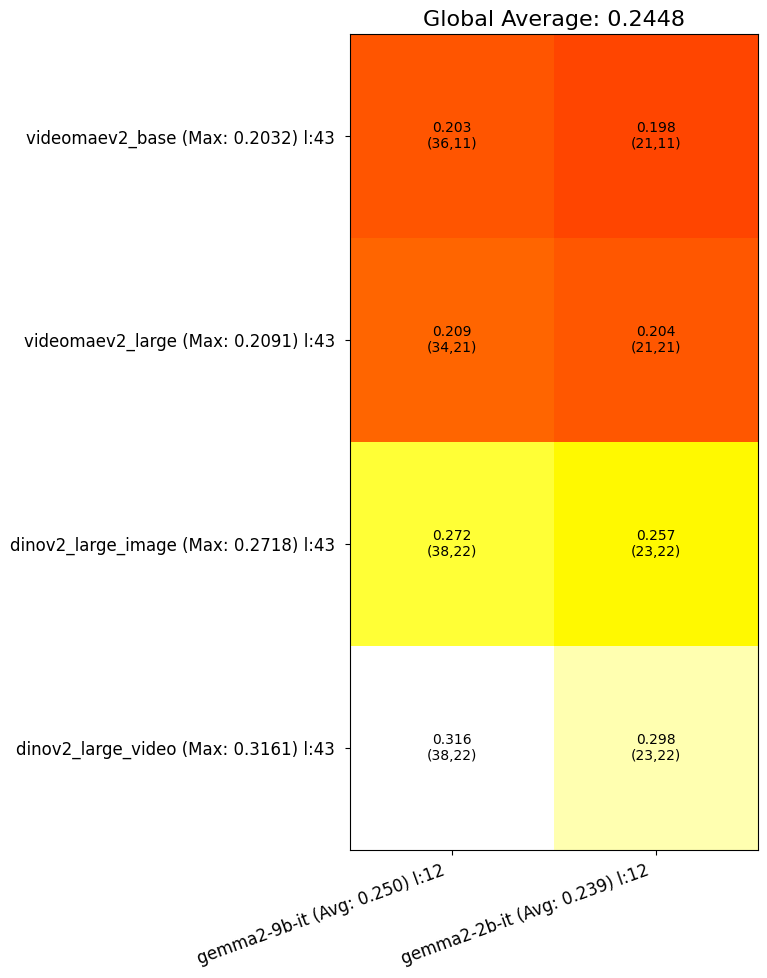

In [11]:
from IPython.display import Image, display
import glob

print("PVD Alignment Plot:")
pvd_plots = glob.glob("results/alignment/sample/pvd/*.png")
for p in pvd_plots:
    display(Image(filename=p))

In [12]:
import os

folder_path = '/content/platonic_rep_video/platonic_rep_video/results/sample/pvd'

if os.path.isdir(folder_path):
    print(f"Contents of {folder_path}:")
    !ls -l {folder_path}
else:
    print(f"The folder {folder_path} does not exist.")

Contents of /content/platonic_rep_video/platonic_rep_video/results/sample/pvd:
total 768328
-rw-r--r-- 1 root root 100664704 May 17 18:49 dinov2_large_image_pool-cls.pt
-rw-r--r-- 1 root root 100664704 May 17 18:48 dinov2_large_video_pool-cls.pt
-rw-r--r-- 1 root root 129394752 May 17 18:52 gemma2-2b-it_pool-avg.pt
-rw-r--r-- 1 root root 317614144 May 17 18:55 gemma2-9b-it_pool-avg.pt
-rw-r--r-- 1 root root  37750129 May 17 18:38 videomaev2_base_pool-avg.pt
-rw-r--r-- 1 root root 100664694 May 17 18:40 videomaev2_large_pool-cls.pt


VIDEO ID: 28393485
CAPTION: A person holds a glass of water, standing in front of a rocky surface.


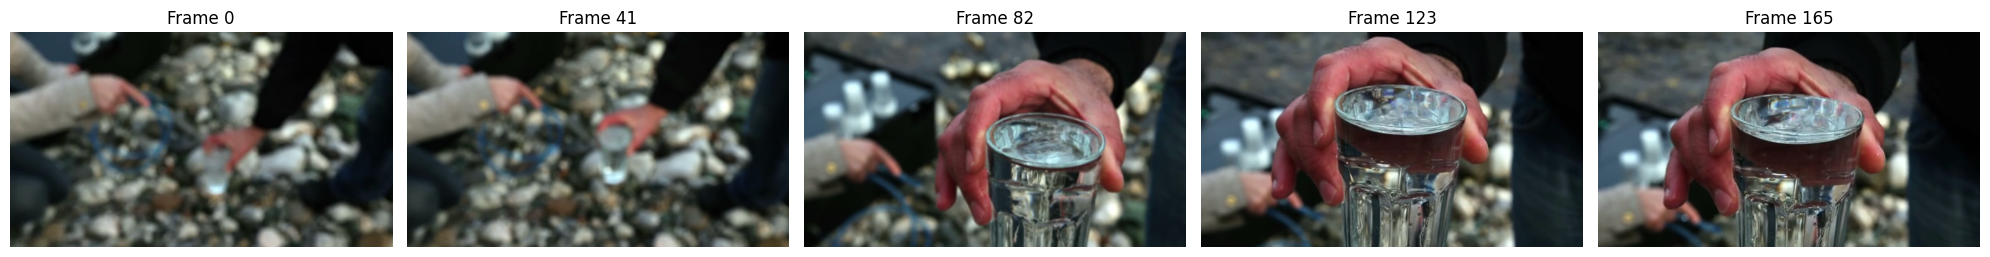


EMBEDDING ANALYSIS
1. Gemma2-9b-it (Layer 38) Vector Shape: torch.Size([3584])
   First 5 values: [ 0.70703125 -1.3515625  -2.28125    -1.1484375  -3.640625  ]

2. DINOv2-Large (Layer 22) Vector Shape: torch.Size([1024])
   First 5 values: [-1.2982882  -0.78006166 -0.16590656  1.0047622   0.51603144]

[NOTE]: You cannot compute 'Cosine Similarity' between a 3584 dimensional vector and a 1024 dimensional vector.
Instead, the Platonic Representation Hypothesis calculates the distance matrix
for ALL 1,024 videos in the DINO space, and ALL 1,024 captions in the Gemma space,
and checks if the distance matrices (neighborhood structures) are correlated!


In [22]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import glob
import cv2

# 1. Load the first video's metadata and caption
jsonl_path = "assets/pe_video_dataset_1k_rephrased.jsonl"
with open(jsonl_path, 'r') as f:
    first_sample = json.loads(f.readline())

video_id = first_sample['video_id']
# FIXED: The correct key for the dataset is 'rephrased_captions'
caption = first_sample['rephrased_captions'][0]

print("="*60)
print(f"VIDEO ID: {video_id}")
print(f"CAPTION: {caption}")
print("="*60)

# 2. Extract and display frames from the video
video_file = glob.glob(f"data/pvd/{video_id}.bin")[0]
cap = cv2.VideoCapture(video_file)

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    # Convert BGR (OpenCV) to RGB (Matplotlib)
    frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

# Display 5 evenly spaced frames
indices = np.linspace(0, len(frames)-1, 5, dtype=int)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in zip(indices, axes):
    ax.imshow(frames[i])
    ax.axis('off')
    ax.set_title(f"Frame {i}")
plt.tight_layout()
plt.show()

# 3. Load the embeddings generated for Gemma2 and DINOv2
# (The files were saved in the results/features directory)

# Try to locate the exact feature files generated
gemma_files = glob.glob("/content/platonic_rep_video/platonic_rep_video/results/sample/pvd/gemma2-9b-it_pool-avg.pt")
dino_files = glob.glob("/content/platonic_rep_video/platonic_rep_video/results/sample/pvd/dinov2_large_video_pool-cls.pt")

if not gemma_files or not dino_files:
    print("\n[!] Could not find feature files. Make sure extraction finished successfully.")
else:
    llm_data = torch.load(gemma_files[0], map_location='cpu')
    vision_data = torch.load(dino_files[0], map_location='cpu')

    llm_feats = llm_data['feats']       # Shape: [Num_Videos, Num_Layers, Hidden_Dim]
    vision_feats = vision_data['feats'] # Shape: [Num_Videos, Num_Layers, Hidden_Dim]

    # The Best Alignment was observed at Gemma Layer 38 and DINOv2 Layer 22
    # Note: Indexing is 0-based, but layers might be 1-based in logs.
    # We'll extract index 38 and 22 for the very first video (Index 0).

    gemma_emb = llm_feats[0, 38, :]
    dino_emb = vision_feats[0, 22, :]

    print("\n" + "="*60)
    print("EMBEDDING ANALYSIS")
    print("="*60)
    print(f"1. Gemma2-9b-it (Layer 38) Vector Shape: {gemma_emb.shape}")
    print(f"   First 5 values: {gemma_emb[:5].float().numpy()}")
    print(f"\n2. DINOv2-Large (Layer 22) Vector Shape: {dino_emb.shape}")
    print(f"   First 5 values: {dino_emb[:5].float().numpy()}")

    print("\n[NOTE]: You cannot compute 'Cosine Similarity' between a", gemma_emb.shape[0],
          "dimensional vector and a", dino_emb.shape[0], "dimensional vector.")
    print("Instead, the Platonic Representation Hypothesis calculates the distance matrix")
    print("for ALL 1,024 videos in the DINO space, and ALL 1,024 captions in the Gemma space,")
    print("and checks if the distance matrices (neighborhood structures) are correlated!")


INFERENCE

In [ ]:
import os
import cv2
import json
import glob
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random

# Ensure vprh is in the path
import sys
sys.path.append('src')
from vprh.registry import llm as llm_registry
from vprh.registry import video as video_registry

print("="*60)
print("LOADING MODELS AND REFERENCE DATASETS")
print("="*60)

# 1. Load Reference Datasets
gemma_files = glob.glob("results/sample/pvd/gemma2-9b-it*.pt")
dino_files = glob.glob("results/sample/pvd/dinov2_large_video*.pt")

# Load Best Layers: Gemma Layer 38, DINOv2 Layer 22
reference_llm_feats = torch.load(gemma_files[0], map_location='cuda', weights_only=False)['feats'][:, 38, :].float()
reference_vision_feats = torch.load(dino_files[0], map_location='cuda', weights_only=False)['feats'][:, 22, :].float()

reference_llm_feats = F.normalize(reference_llm_feats, p=2, dim=-1)
reference_vision_feats = F.normalize(reference_vision_feats, p=2, dim=-1)

# 2. Load Models
print("Loading DINOv2 Large...")
video_model = video_registry.VIDEO_MODEL_REGISTRY['dinov2_large_video']
video_model.to('cuda')

print("Loading Gemma2-9B-IT...")
llm_cfg = llm_registry.LLM_REGISTRY['gemma2-9b-it']
tokenizer = llm_registry.create_tokenizer(llm_cfg)
language_model = llm_registry.create_llm(llm_cfg, quantize=False, force_download=False).to('cuda')

# 3. Helper Functions
def extract_video_feature(video_path, num_frames):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    # Sample the requested number of frames evenly
    indices = np.linspace(0, len(frames)-1, num_frames, dtype=int)
    sampled_frames = [frames[i] for i in indices]

    inputs = video_model.preprocess(sampled_frames).unsqueeze(0).to('cuda')
    with torch.no_grad():
        outputs = video_model.forward_intermediates(inputs, pool='avg')
        feat = outputs[:, 22, :].float()
        return F.normalize(feat, p=2, dim=-1)

def extract_text_feature(captions_list, num_captions):
    # Combine the requested number of captions
    combined_text = " ".join(captions_list[:num_captions])
    tokens = tokenizer([combined_text], padding='longest', return_tensors='pt')
    tokens = {k: v.to('cuda') for k, v in tokens.items()}
    with torch.no_grad():
        output = language_model(input_ids=tokens['input_ids'],
                                attention_mask=tokens['attention_mask'],
                                output_hidden_states=True)
        feat = output['hidden_states'][38][:, -1, :].float()
        return F.normalize(feat, p=2, dim=-1)

def calculate_overlap(vid_feat, txt_feat, k=10):
    vid_similarities = vid_feat @ reference_vision_feats.T
    _, vid_neighbors = torch.topk(vid_similarities, k, dim=-1)

    txt_similarities = txt_feat @ reference_llm_feats.T
    _, txt_neighbors = torch.topk(txt_similarities, k, dim=-1)

    v_set = set(vid_neighbors[0].tolist())
    t_set = set(txt_neighbors[0].tolist())
    return len(v_set.intersection(t_set)) / k

# ------------------------------------------------------------------------
# THE DEMO EXPERIMENT
# ------------------------------------------------------------------------
print("\n" + "="*60)
print("RUNNING DEMO EXPERIMENTS")
print("="*60)

# Pick a random video from our dataset
jsonl_path = "assets/pe_video_dataset_1k_rephrased.jsonl"
with open(jsonl_path, 'r') as f:
    all_samples = [json.loads(line) for line in f]

sample = random.choice(all_samples)
video_path = f"data/pvd/{sample['video_id']}.bin"
all_captions = sample['rephrased_captions']
total_caps = len(all_captions)

print(f"Selected Video ID: {sample['video_id']}")
print(f"Total available captions for this video: {total_caps}")

# --- EXPERIMENT 1: Varying Frames (Constant Captions) ---
print("\n[Experiment 1] Varying number of frames (Captions fixed at max)")
frame_counts = [1, 4, 16]
frame_scores = []

# Keep text constant at max captions
max_text_feat = extract_text_feature(all_captions, total_caps)

for f_count in frame_counts:
    v_feat = extract_video_feature(video_path, f_count)
    score = calculate_overlap(v_feat, max_text_feat)
    frame_scores.append(score)
    print(f" -> {f_count} Frames Alignment Score: {score*100:.1f}%")

# --- EXPERIMENT 2: Varying Captions (Constant Frames) ---
print("\n[Experiment 2] Varying number of captions (Frames fixed at 16)")
caption_counts = [1, 3, total_caps]
caption_scores = []

# Keep video constant at 16 frames
max_vid_feat = extract_video_feature(video_path, 16)

for c_count in caption_counts:
    t_feat = extract_text_feature(all_captions, c_count)
    score = calculate_overlap(max_vid_feat, t_feat)
    caption_scores.append(score)
    print(f" -> {c_count} Captions Alignment Score: {score*100:.1f}%")

# ------------------------------------------------------------------------
# PLOTTING THE RESULTS
# ------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Information Density Increases Vision-Text Alignment", fontsize=16, fontweight='bold')

# Plot 1: Frames
ax1.bar([str(x) for x in frame_counts], [s * 100 for s in frame_scores], color='#3498db')
ax1.set_title("Exp 1: Increasing Video Frames", fontsize=14)
ax1.set_xlabel("Number of Frames Sampled")
ax1.set_ylabel("Neighborhood Overlap (%)")
ax1.set_ylim(0, max(max(frame_scores), max(caption_scores))*100 + 10)
for i, v in enumerate(frame_scores):
    ax1.text(i, (v*100) + 1, f"{v*100:.1f}%", ha='center', fontweight='bold')

# Plot 2: Captions
ax2.bar([str(x) for x in caption_counts], [s * 100 for s in caption_scores], color='#2ecc71')
ax2.set_title("Exp 2: Increasing Caption Detail", fontsize=14)
ax2.set_xlabel("Number of Captions Concatenated")
ax2.set_ylabel("Neighborhood Overlap (%)")
ax2.set_ylim(0, max(max(frame_scores), max(caption_scores))*100 + 10)
for i, v in enumerate(caption_scores):
    ax2.text(i, (v*100) + 1, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()